We will perform K-means to cluster based only on text reclamation

In [24]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import silhouette_score




df = pd.read_csv("../data/Reclamations_clean.csv")

In [25]:
tfidf = TfidfVectorizer(
    min_df=1,        
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df['texte_reclamation'].tolist())
X_text = X

We will perform the elbow method to determine the best K for our clustering

Optimal k selected by elbow method: 5


C:\Users\wassi\AppData\Local\Temp\ipykernel_8216\1692120997.py:18: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return np.abs(np.cross(end - start, start - point)) / np.linalg.norm(end - start)


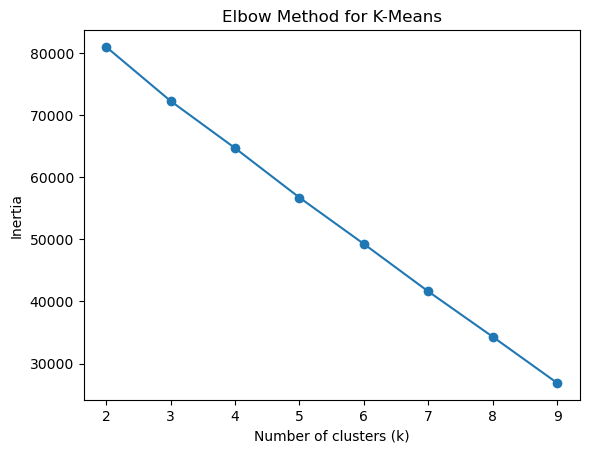

In [26]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)


points = np.column_stack((list(K_range), inertia))


start = points[0]
end = points[-1]


def distance_to_line(point, start, end):
    return np.abs(np.cross(end - start, start - point)) / np.linalg.norm(end - start)

distances = [distance_to_line(p, start, end) for p in points]

# Elbow is the point with maximum distance
optimal_k = K_range[np.argmax(distances)]

print("Optimal k selected by elbow method:", optimal_k)

# Plot elbow curve
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

In [27]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['text_cluster'] = kmeans.fit_predict(X)   # ✅ STORE TEXT CLUSTERS
text_clusters = df['text_cluster']           # ✅ STORE LABELS

In [28]:
terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(optimal_k):
    print(f"\nCluster {i} top terms:")
    for ind in order_centroids[i, :8]:
        print(terms[ind], end=" | ")


Cluster 0 top terms:
ne | ne se | synchronise pas | synchronise | modem ne | modem | se synchronise | se | 
Cluster 1 top terms:
lors | lors de | de la | de | la | authentification | connexion | la connexion | 
Cluster 2 top terms:
en soirée | faible | très | débit très | très faible | en | débit | soirée | 
Cluster 3 top terms:
sur | demande | figée sur | figée | image figée | certaines chaines | certaines | chaines | 
Cluster 4 top terms:
installation non | délais | réalisée dans | réalisée | non réalisée | non | les délais | les | 

In [29]:
df[['texte_reclamation', 'text_cluster']].head(10)
#interpretation of clusters :

,texte_reclamation,text_cluster
0,Incident: modem ne se synchronise pas.,0
1,Client signale problème lors de la résiliation...,1
2,Demande d'assistance: bruit important sur la l...,3
3,"Incident: problème lors de la résiliation, fac...",1
4,Incident: installation non réalisée dans les d...,4
5,Demande d'assistance: image figée sur certaine...,3
6,Demande d'assistance: montant facturé incorrec...,3
7,"Réclamation: montant facturé incorrectement, d...",3
8,Client signale demande d'information sur l'off...,3
9,Réclamation: erreur d'authentification lors de...,1


now we will perform K-Means on the categorical data : using partitional clustering

In [30]:
features = ['category', 'region', 'sentiment']
df_cat = df[features].dropna()

In [31]:
encoder = OneHotEncoder(handle_unknown='ignore')

X = encoder.fit_transform(df)
X_cat = X

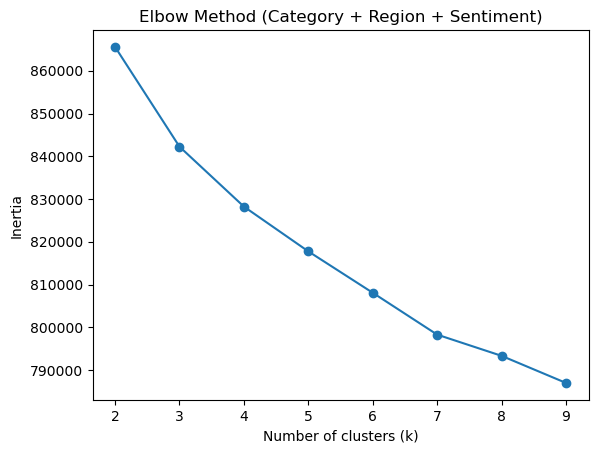

In [32]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (Category + Region + Sentiment)")
plt.show()

In [33]:
k = 4 # from the graph of elbow method we can see that the best k is 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df_cat['cat_cluster'] = kmeans.fit_predict(X)   # ✅ STORE CAT CLUSTERS
cat_clusters = df_cat['cat_cluster']  

In [35]:
pd.crosstab(df_cat['cat_cluster'], df_cat['category']) #we print the results for each cluster based on each col

category,Assistance,Autre,Configuration,Coupure De Ligne,Facturation,Installation,Internet Lent,Problème Matériel,Résiliation,Télévision
cat_cluster,,,,,,,,,,
0,2331,582,1147,6692,3530,2978,5947,1836,1834,3006
1,1962,497,979,5558,2953,2389,4909,1425,1475,2472
2,1942,478,978,5414,2904,2453,4932,1385,1539,2450
3,1673,409,850,4711,2504,2051,4246,1233,1253,2093


In [36]:
pd.crosstab(df_cat['cat_cluster'], df_cat['region'])


region,Adrar,Alger,Annaba,Batna,Biskra,Blida,Boumerdès,Béjaïa,Chlef,Constantine,...,Oran,Ouargla,Relizane,Saïda,Sidi Bel Abbès,Skikda,Sétif,Tiaret,Tizi Ouzou,Tlemcen
cat_cluster,,,,,,,,,,,,,,,,,,,,,
0,1063,1072,1157,1174,1127,1088,1062,1125,1121,1116,...,1065,1052,1058,1085,1142,1094,1128,1145,1106,1090
1,915,888,920,925,924,875,953,905,901,884,...,936,893,917,898,877,917,875,875,945,883
2,915,832,912,897,940,943,894,910,919,898,...,972,878,914,875,854,907,953,910,901,916
3,779,762,789,761,758,834,742,803,784,781,...,778,743,802,772,788,758,779,790,797,788


In [37]:
pd.crosstab(df_cat['cat_cluster'], df_cat['sentiment'])

sentiment,Neutre,Négatif,Positif
cat_cluster,,,
0,29883,0,0
1,0,21127,3492
2,0,20989,3486
3,0,18051,2972


patterns are going to be determined soon
computing silhouette coeficient to evaluate the clustering

In [40]:
sil_text = silhouette_score(
    X_text,
    text_clusters,
    sample_size=1000,  # use sampling to speed up computation
    random_state=42
)

print("Silhouette score (Text / TF-IDF):", sil_text)

# ===============================
# 2️⃣ Silhouette for CATEGORICAL FEATURE CLUSTERING
# ===============================
# X_cat = one-hot encoded categorical features
# cat_clusters = df_cat['cat_cluster']

sil_cat = silhouette_score(
    X_cat,
    cat_clusters,
    sample_size=1000,  # also use sampling here
    random_state=42
)

print("Silhouette score (Categorical):", sil_cat)

# ===============================
# 3️⃣ Compare clustering quality
# ===============================
if sil_text > sil_cat:
    print("→ Text-based clustering performs better according to silhouette score.")
else:
    print("→ Categorical-feature clustering performs better according to silhouette score.")

# ===============================
# 4️⃣ Interpret categorical clusters (optional)
# ===============================
print("\nCross-tabulation of clusters vs category:")
print(pd.crosstab(df_cat['cat_cluster'], df_cat['category']))

print("\nCross-tabulation of clusters vs region:")
print(pd.crosstab(df_cat['cat_cluster'], df_cat['region']))

print("\nCross-tabulation of clusters vs sentiment:")
print(pd.crosstab(df_cat['cat_cluster'], df_cat['sentiment']))

Silhouette score (Text / TF-IDF): 0.2932964740724089
Silhouette score (Categorical): 0.039172900737127224
→ Text-based clustering performs better according to silhouette score.

Cross-tabulation of clusters vs category:
category     Assistance  Autre  Configuration  Coupure De Ligne  Facturation  \
cat_cluster                                                                    
0                  2331    582           1147              6692         3530   
1                  1962    497            979              5558         2953   
2                  1942    478            978              5414         2904   
3                  1673    409            850              4711         2504   

category     Installation  Internet Lent  Problème Matériel  Résiliation  \
cat_cluster                                                                
0                    2978           5947               1836         1834   
1                    2389           4909               1425         147